Téléchargement FRED – US_HY_OAS (BAMLH0A0HYM2)...
Téléchargement FRED – EU_HY_OAS (BAMLHE00EHYIOAS)...
Téléchargement FRED – US_BB_HY_OAS (BAMLH0A1HYBB)...
Téléchargement FRED – US_IG_OAS (BAMLC0A0CM)...
Téléchargement FRED – US_2Y (DGS2)...
Téléchargement FRED – US_5Y (DGS5)...
Téléchargement FRED – US_10Y (DGS10)...
Téléchargement FRED – US_2s10s (T10Y2Y)...
Téléchargement FRED – US_10Y_Breakeven (T10YIE)...
OK – fichiers écrits (CSV + XLSX).

=== SYNTHÈSE FRED + YAHOO (valeur actuelle + moyenne 10 ans) ===


label        asof  \
source name                                                                
FRED   US_HY_OAS            ICE BofA US High Yield Index OAS  2026-02-06   
       EU_HY_OAS          ICE BofA Euro High Yield Index OAS  2026-02-06   
       US_BB_HY_OAS      ICE BofA BB US High Yield Index OAS  2026-02-06   
       US_IG_OAS             ICE BofA US Corporate Index OAS  2026-02-06   
       US_2Y                            US 2Y Treasury yield  2026-02-06   
       US_5Y                            US 5Y Treasury yield  2026-02-06   
       US_10Y                          US 10Y Treasury yield  2026-02-06   
       US_2s10s                    US 10Y–2Y Treasury spread  2026-02-09   
       US_10Y_Breakeven           US 10Y breakeven inflation  2026-02-09   
       HY_IG_OAS_SPREAD                US HY – IG OAS spread  2026-02-06   
Yahoo  MOVE_Index              ICE BofA MOVE Index (Tsy vol)  2026-02-09   
       HYG_LQD_ratio                    HYG / LQD (HY vs IG)  2026-02-09   
       XLY_XLP_ratio                  XLY / XLP (cyc vs def)  2026-02-09   
       XTC5_5Y_perf      Xtrackers II iTraxx Crossover Short  2026-02-10   

                         current  mean_10y         unit  \
source name                                               
FRED   US_HY_OAS          287.00    406.22          bps   
       EU_HY_OAS          261.00    385.09          bps   
       US_BB_HY_OAS       171.00    263.14          bps   
       US_IG_OAS           76.00    120.11          bps   
       US_2Y                3.50      2.34            %   
       US_5Y                3.76      2.46            %   
       US_10Y               4.22      2.72            %   
       US_2s10s            74.00     37.88          bps   
       US_10Y_Breakeven     2.35      2.06            %   
       HY_IG_OAS_SPREAD   211.00    286.16          bps   
Yahoo  MOVE_Index          62.74     79.98        index   
       HYG_LQD_ratio        0.73      0.64        ratio   
       XLY_XLP_ratio        1.34      1.17        ratio   
       XTC5_5Y_perf       -21.97       NaN  % sur 5 ans   

                                                                  comment  
source name                                                                
FRED   US_HY_OAS                         US HY OAS (crédit high yield US)  
       EU_HY_OAS                     Euro HY OAS (crédit high yield euro)  
       US_BB_HY_OAS                       US BB HY OAS (segment BB du HY)  
       US_IG_OAS         US IG corporate OAS (crédit investment grade US)  
       US_2Y                                        Taux nominal US 2 ans  
       US_5Y                                        Taux nominal US 5 ans  
       US_10Y                                      Taux nominal US 10 ans  
       US_2s10s                           Spread 10Y–2Y (pente de courbe)  
       US_10Y_Breakeven       Inflation implicite 10 ans (nominal – TIPS)  
       HY_IG_OAS_SPREAD        Prime de risque HY vs IG (OAS HY – OAS IG)  
Yahoo  MOVE_Index                             Vol implicite US Treasuries  
       HYG_LQD_ratio                               Ratio HY/IG via ETF US  
       XLY_XLP_ratio              Ratio secteurs cycliques / défensifs US  
       XTC5_5Y_perf                            ETF short iTraxx Crossover


=== SNAPSHOTS HY / IG (bps) ===


,Date_effective,US_HY_OAS_bps,US_IG_OAS_bps,HY_minus_IG_bps
Snapshot,,,,
Today,2026-02-06,287.0,76.0,211.0
3M_ago,2025-11-06,313.0,82.0,231.0
6M_ago,2025-08-06,298.0,81.0,217.0
1Y_ago,2025-02-06,266.0,84.0,182.0
3Y_ago,2023-02-06,399.0,120.0,279.0
5Y_ago,2021-02-05,358.0,99.0,259.0
10Y_ago,2015-11-10,602.0,161.0,441.0
15Y_ago,2010-11-10,575.0,175.0,400.0



=== SPREAD HY – IG (OAS) – historique + moyenne 10 ans ± 1σ ===


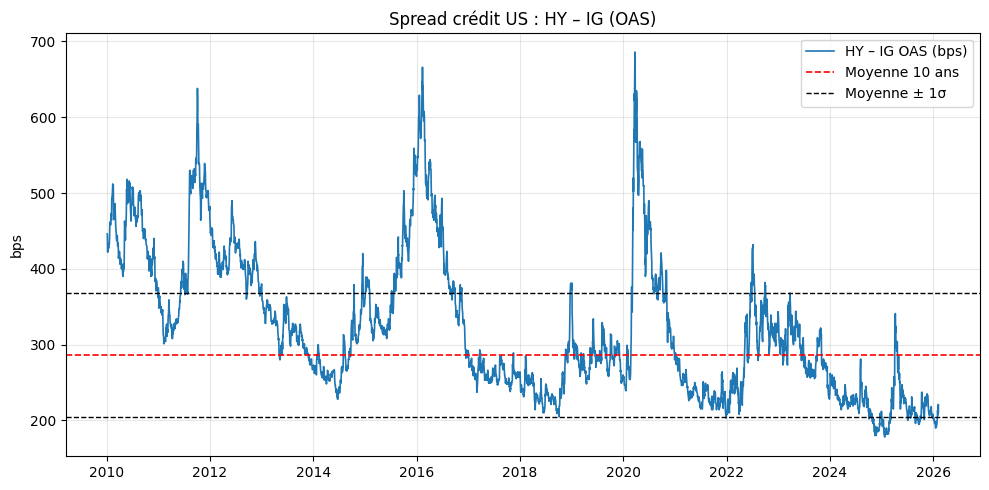

In [20]:
import os
import warnings
import requests
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Optional (only if you run in Jupyter)
try:
    from IPython.display import display
    HAS_IPYTHON = True
except Exception:
    HAS_IPYTHON = False


# =====================================================================
# 0. WARNINGS (optional)
# =====================================================================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# =====================================================================
# 1. CONFIG
# =====================================================================

# Best practice: put your key in env var FRED_API_KEY
# export FRED_API_KEY="xxxx"
FRED_API_KEY = os.getenv("FRED_API_KEY", "31692517396dd6b0c5bebdebc99e4990")
START_DATE = "2010-01-01"

# Séries FRED principales
FRED_SERIES = {
    # Credit spreads (OAS)
    "US_HY_OAS": {
        "fred_id": "BAMLH0A0HYM2",
        "label": "ICE BofA US High Yield Index OAS",
        "comment": "US HY OAS (crédit high yield US)",
        "display_unit": "bps",  # raw is in % points on FRED
    },
    "EU_HY_OAS": {
        "fred_id": "BAMLHE00EHYIOAS",
        "label": "ICE BofA Euro High Yield Index OAS",
        "comment": "Euro HY OAS (crédit high yield euro)",
        "display_unit": "bps",
    },
    "US_BB_HY_OAS": {
        "fred_id": "BAMLH0A1HYBB",
        "label": "ICE BofA BB US High Yield Index OAS",
        "comment": "US BB HY OAS (segment BB du HY)",
        "display_unit": "bps",
    },
    "US_IG_OAS": {
        "fred_id": "BAMLC0A0CM",
        "label": "ICE BofA US Corporate Index OAS",
        "comment": "US IG corporate OAS (crédit investment grade US)",
        "display_unit": "bps",
    },

    # Courbe US
    "US_2Y": {
        "fred_id": "DGS2",
        "label": "US 2Y Treasury yield",
        "comment": "Taux nominal US 2 ans",
        "display_unit": "%",
    },
    "US_5Y": {
        "fred_id": "DGS5",
        "label": "US 5Y Treasury yield",
        "comment": "Taux nominal US 5 ans",
        "display_unit": "%",
    },
    "US_10Y": {
        "fred_id": "DGS10",
        "label": "US 10Y Treasury yield",
        "comment": "Taux nominal US 10 ans",
        "display_unit": "%",
    },
    "US_2s10s": {
        "fred_id": "T10Y2Y",
        "label": "US 10Y–2Y Treasury spread",
        "comment": "Spread 10Y–2Y (pente de courbe)",
        "display_unit": "bps",  # raw is in % points, we display in bps
    },

    # Inflation anticipée
    "US_10Y_Breakeven": {
        "fred_id": "T10YIE",
        "label": "US 10Y breakeven inflation",
        "comment": "Inflation implicite 10 ans (nominal – TIPS)",
        "display_unit": "%",
    },
}

# Tickers Yahoo
YAHOO_TICKERS = {
    "MOVE_Index": {
        "ticker": "^MOVE",
        "label": "ICE BofA MOVE Index (Tsy vol)",
        "comment": "Vol implicite US Treasuries",
    },
    "HYG": {
        "ticker": "HYG",
        "label": "iShares iBoxx $ High Yield Corp Bond ETF",
        "comment": "ETF HY US",
    },
    "LQD": {
        "ticker": "LQD",
        "label": "iShares iBoxx $ Investment Grade Corp Bond ETF",
        "comment": "ETF IG US",
    },
    "XLY": {
        "ticker": "XLY",
        "label": "Consumer Discretionary Select Sector SPDR",
        "comment": "Secteur cyclique US",
    },
    "XLP": {
        "ticker": "XLP",
        "label": "Consumer Staples Select Sector SPDR",
        "comment": "Secteur défensif US",
    },
    # ETF iTraxx crossover (à vérifier si ce ticker existe bien chez Yahoo)
    "XTC5": {
        "ticker": "XTC5.DE",
        "label": "Xtrackers II iTraxx Crossover Short",
        "comment": "ETF short iTraxx Crossover",
    },
}


# =====================================================================
# 2. HELPERS (units / robust display)
# =====================================================================

def to_bps(x: float) -> float:
    """Convert raw % points to bps (e.g., 4.20 -> 420 bps)."""
    return x * 100.0

def safe_display_df(df: pd.DataFrame, title: str | None = None, round_map: dict | None = None) -> None:
    """Display in Jupyter if available, else print."""
    if title:
        print(title)
    if round_map:
        df_to_show = df.round(round_map)
    else:
        df_to_show = df

    if HAS_IPYTHON:
        display(df_to_show)
    else:
        print(df_to_show)


# =====================================================================
# 3. FONCTIONS FRED
# =====================================================================

def get_fred_series(series_id: str, start: str = START_DATE, api_key: str = FRED_API_KEY) -> pd.Series:
    """Télécharge une série FRED et renvoie une Series pandas."""
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    obs = r.json().get("observations", [])

    dates = []
    values = []
    for o in obs:
        dates.append(o["date"])
        v = o["value"]
        values.append(float(v) if v not in (".", "", None) else float("nan"))

    s = pd.Series(values, index=pd.to_datetime(dates), name=series_id).sort_index()
    return s


def fetch_all_fred_series(start: str = START_DATE) -> pd.DataFrame:
    """Télécharge toutes les séries FRED définies dans FRED_SERIES."""
    series_dict = {}
    for name, meta in FRED_SERIES.items():
        fred_id = meta["fred_id"]
        print(f"Téléchargement FRED – {name} ({fred_id})...")
        s = get_fred_series(fred_id, start=start)
        s.name = name
        series_dict[name] = s

    df = pd.concat(series_dict.values(), axis=1).sort_index()
    return df


def build_fred_summary(fred_df: pd.DataFrame) -> pd.DataFrame:
    """Tableau synthétique FRED : valeur actuelle + moyenne 10 ans (affichage bps ou %)."""
    rows = []

    for name, meta in FRED_SERIES.items():
        if name not in fred_df.columns:
            continue

        s = fred_df[name].dropna()
        if s.empty:
            continue

        last_date = s.index.max()
        current = float(s.loc[last_date])
        start_10y = last_date - pd.DateOffset(years=10)
        s_10y = s.loc[start_10y:]
        mean_10y = float(s_10y.mean()) if not s_10y.empty else None

        disp_unit = meta.get("display_unit", "%")
        if disp_unit == "bps":
            current_disp = to_bps(current)
            mean_10y_disp = to_bps(mean_10y) if mean_10y is not None else None
        else:
            current_disp = current
            mean_10y_disp = mean_10y

        rows.append({
            "source": "FRED",
            "name": name,
            "label": meta["label"],
            "asof": last_date.date(),
            "current": current_disp,
            "mean_10y": mean_10y_disp,
            "unit": disp_unit,
            "comment": meta["comment"],
        })

    # Spread dérivé HY – IG (raw % points; display bps)
    if {"US_HY_OAS", "US_IG_OAS"}.issubset(fred_df.columns):
        s_spread = (fred_df["US_HY_OAS"] - fred_df["US_IG_OAS"]).dropna()
        if not s_spread.empty:
            last_date = s_spread.index.max()
            start_10y = last_date - pd.DateOffset(years=10)
            s_10y = s_spread.loc[start_10y:]
            mean_10y = float(s_10y.mean()) if not s_10y.empty else None

            rows.append({
                "source": "FRED",
                "name": "HY_IG_OAS_SPREAD",
                "label": "US HY – IG OAS spread",
                "asof": last_date.date(),
                "current": to_bps(float(s_spread.loc[last_date])),
                "mean_10y": to_bps(mean_10y) if mean_10y is not None else None,
                "unit": "bps",
                "comment": "Prime de risque HY vs IG (OAS HY – OAS IG)",
            })

    return pd.DataFrame(rows)


# =====================================================================
# 4. FONCTIONS YAHOO
# =====================================================================

def get_yahoo_series(ticker: str, start: str = START_DATE) -> pd.Series:
    """
    Télécharge la série de prix Yahoo pour un ticker.
    Gère colonnes simples et MultiIndex.
    """
    data = yf.download(
        ticker,
        start=start,
        progress=False,
        auto_adjust=False,
    )

    if data is None or data.empty:
        print(f"Attention : pas de données Yahoo pour {ticker}")
        return pd.Series(dtype=float)

    cols = data.columns

    # Cas colonnes simples
    if not isinstance(cols, pd.MultiIndex):
        if "Adj Close" in cols:
            s = data["Adj Close"].copy()
        elif "Close" in cols:
            s = data["Close"].copy()
        else:
            raise KeyError(f"Aucune colonne 'Adj Close' ou 'Close' pour {ticker}. Colonnes: {list(cols)}")

    # Cas MultiIndex (rare ici, mais on le gère)
    else:
        adj_cols = [c for c in cols if c[0] == "Adj Close"]
        close_cols = [c for c in cols if c[0] == "Close"]

        if adj_cols:
            s = data[adj_cols[0]].copy()
        elif close_cols:
            s = data[close_cols[0]].copy()
        else:
            raise KeyError(f"Aucune colonne 'Adj Close' ou 'Close' (MultiIndex) pour {ticker}. Colonnes: {list(cols)}")

    s = s.dropna()
    s.name = ticker
    return s


def build_yahoo_summary(start: str = START_DATE) -> tuple[pd.DataFrame, dict]:
    """
    Construit :
    - un tableau synthétique pour MOVE, ratios HYG/LQD, XLY/XLP, perf 5 ans XTC5
    - un dict de séries brutes (pour graph).
    """
    series_raw: dict[str, pd.Series] = {}
    rows = []

    # 1) Récupération séries brutes
    for key, meta in YAHOO_TICKERS.items():
        s = get_yahoo_series(meta["ticker"], start=start)
        series_raw[key] = s

    # 2) MOVE : niveau actuel + moyenne 10 ans
    move = series_raw.get("MOVE_Index", pd.Series(dtype=float))
    if not move.empty:
        last_date = move.index.max()
        start_10y = last_date - pd.DateOffset(years=10)
        move_10y = move.loc[start_10y:]
        rows.append({
            "source": "Yahoo",
            "name": "MOVE_Index",
            "label": YAHOO_TICKERS["MOVE_Index"]["label"],
            "asof": last_date.date(),
            "current": float(move.loc[last_date]),
            "mean_10y": float(move_10y.mean()) if not move_10y.empty else None,
            "unit": "index",
            "comment": YAHOO_TICKERS["MOVE_Index"]["comment"],
        })

    # 3) Ratio HYG/LQD
    hyg = series_raw.get("HYG", pd.Series(dtype=float))
    lqd = series_raw.get("LQD", pd.Series(dtype=float))
    if not hyg.empty and not lqd.empty:
        ratio = (hyg / lqd).dropna()
        last_date = ratio.index.max()
        start_10y = last_date - pd.DateOffset(years=10)
        r_10y = ratio.loc[start_10y:]
        rows.append({
            "source": "Yahoo",
            "name": "HYG_LQD_ratio",
            "label": "HYG / LQD (HY vs IG)",
            "asof": last_date.date(),
            "current": float(ratio.loc[last_date]),
            "mean_10y": float(r_10y.mean()) if not r_10y.empty else None,
            "unit": "ratio",
            "comment": "Ratio HY/IG via ETF US",
        })

    # 4) Ratio XLY/XLP
    xly = series_raw.get("XLY", pd.Series(dtype=float))
    xlp = series_raw.get("XLP", pd.Series(dtype=float))
    if not xly.empty and not xlp.empty:
        ratio = (xly / xlp).dropna()
        last_date = ratio.index.max()
        start_10y = last_date - pd.DateOffset(years=10)
        r_10y = ratio.loc[start_10y:]
        rows.append({
            "source": "Yahoo",
            "name": "XLY_XLP_ratio",
            "label": "XLY / XLP (cyc vs def)",
            "asof": last_date.date(),
            "current": float(ratio.loc[last_date]),
            "mean_10y": float(r_10y.mean()) if not r_10y.empty else None,
            "unit": "ratio",
            "comment": "Ratio secteurs cycliques / défensifs US",
        })

    # 5) Perf 5 ans de XTC5
    xtc5 = series_raw.get("XTC5", pd.Series(dtype=float))
    if not xtc5.empty:
        last_date = xtc5.index.max()
        start_5y = last_date - pd.DateOffset(years=5)
        xtc5_5y = xtc5.loc[start_5y:]
        perf_5y = None
        if not xtc5_5y.empty:
            price_5y_ago = float(xtc5_5y.iloc[0])
            perf_5y = float(xtc5.loc[last_date] / price_5y_ago - 1.0)

        rows.append({
            "source": "Yahoo",
            "name": "XTC5_5Y_perf",
            "label": YAHOO_TICKERS["XTC5"]["label"],
            "asof": last_date.date(),
            "current": (perf_5y * 100.0) if perf_5y is not None else None,
            "mean_10y": None,
            "unit": "% sur 5 ans",
            "comment": YAHOO_TICKERS["XTC5"]["comment"],
        })

    return pd.DataFrame(rows), series_raw


# =====================================================================
# 5. SNAPSHOTS HY/IG + GRAPHE (HY–IG)
# =====================================================================

def build_hy_ig_snapshots(fred_df: pd.DataFrame) -> pd.DataFrame:
    """
    Construit un tableau de snapshots HY / IG / spread aux horizons:
    Today, 3M, 6M, 1Y, 3Y, 5Y, + deux dates fixes (2015-11-10, 2010-11-10).
    Affichage en bps.
    """
    required = {"US_HY_OAS", "US_IG_OAS"}
    if not required.issubset(fred_df.columns):
        return pd.DataFrame()

    df = fred_df[["US_HY_OAS", "US_IG_OAS"]].dropna().copy()
    if df.empty:
        return pd.DataFrame()

    df["HY_IG_spread_raw"] = df["US_HY_OAS"] - df["US_IG_OAS"]
    last_date = df.index.max()

    snap_targets = {
        "Today":   last_date,
        "3M_ago":  last_date - pd.DateOffset(months=3),
        "6M_ago":  last_date - pd.DateOffset(months=6),
        "1Y_ago":  last_date - pd.DateOffset(years=1),
        "3Y_ago":  last_date - pd.DateOffset(years=3),
        "5Y_ago":  last_date - pd.DateOffset(years=5),
        "10Y_ago": pd.Timestamp("2015-11-10"),
        "15Y_ago": pd.Timestamp("2010-11-10"),
    }

    rows = []
    for lbl, target_date in snap_targets.items():
        sub = df.loc[:target_date].dropna()
        if sub.empty:
            continue
        eff_date = sub.index.max()
        row = sub.loc[eff_date].copy()
        rows.append({
            "Snapshot": lbl,
            "Date_effective": eff_date.date(),
            "US_HY_OAS_bps": to_bps(float(row["US_HY_OAS"])),
            "US_IG_OAS_bps": to_bps(float(row["US_IG_OAS"])),
            "HY_minus_IG_bps": to_bps(float(row["HY_IG_spread_raw"])),
        })

    out = pd.DataFrame(rows).set_index("Snapshot")
    return out


def plot_hy_ig_spread_10y_band(fred_df: pd.DataFrame) -> None:
    """Trace HY–IG OAS (en bps) + moyenne 10 ans ± 1σ."""
    if not {"US_HY_OAS", "US_IG_OAS"}.issubset(fred_df.columns):
        print("Colonnes US_HY_OAS / US_IG_OAS absentes.")
        return

    s = (fred_df["US_HY_OAS"] - fred_df["US_IG_OAS"]).dropna()
    if s.empty:
        print("Pas de données non vides pour HY–IG.")
        return

    # Work in bps for the plot
    s_bps = s * 100.0

    last_date = s_bps.index.max()
    start_10y = last_date - pd.DateOffset(years=10)
    s_10y = s_bps.loc[start_10y:]

    mu_10 = float(s_10y.mean())
    sig_10 = float(s_10y.std())

    plt.figure(figsize=(10, 5))
    plt.plot(s_bps.index, s_bps.values, label="HY – IG OAS (bps)", linewidth=1.2)

    plt.axhline(mu_10, color="red", linestyle="--", linewidth=1.2, label="Moyenne 10 ans")
    plt.axhline(mu_10 + sig_10, color="black", linestyle="--", linewidth=1.0, label="Moyenne ± 1σ")
    plt.axhline(mu_10 - sig_10, color="black", linestyle="--", linewidth=1.0)

    plt.title("Spread crédit US : HY – IG (OAS)")
    plt.ylabel("bps")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =====================================================================
# 6. MAIN
# =====================================================================

def main() -> None:
    # 6.1 FRED
    fred_df = fetch_all_fred_series(START_DATE)

    # Derived series (raw % points)
    if {"US_HY_OAS", "US_IG_OAS"}.issubset(fred_df.columns):
        fred_df["HY_IG_spread_raw"] = fred_df["US_HY_OAS"] - fred_df["US_IG_OAS"]

    fred_summary = build_fred_summary(fred_df)

    # 6.2 Yahoo
    yahoo_summary, yahoo_series = build_yahoo_summary(START_DATE)

    # 6.3 Global table
    summary_table = pd.concat([fred_summary, yahoo_summary], ignore_index=True)

    # 6.4 Exports
    fred_df.to_csv("macro_fred_timeseries.csv", index_label="Date")
    summary_table.to_csv("macro_summary_fred_yahoo.csv", index=False)

    fred_df.to_excel("macro_fred_timeseries.xlsx", sheet_name="fred_ts")
    summary_table.to_excel("macro_summary_fred_yahoo.xlsx", sheet_name="summary", index=False)

    print("OK – fichiers écrits (CSV + XLSX).")

    # 6.5 Affichage synthétique (sans .style -> pas besoin de jinja2)
    safe_display_df(
        summary_table.set_index(["source", "name"]),
        title="\n=== SYNTHÈSE FRED + YAHOO (valeur actuelle + moyenne 10 ans) ===",
        round_map={"current": 2, "mean_10y": 2},
    )

    # 6.6 Snapshots HY/IG
    snaps = build_hy_ig_snapshots(fred_df)
    if not snaps.empty:
        safe_display_df(
            snaps,
            title="\n=== SNAPSHOTS HY / IG (bps) ===",
            round_map={"US_HY_OAS_bps": 1, "US_IG_OAS_bps": 1, "HY_minus_IG_bps": 1},
        )
    else:
        print("\nPas de snapshots HY/IG (données manquantes).")

    # 6.7 Plot
    print("\n=== SPREAD HY – IG (OAS) – historique + moyenne 10 ans ± 1σ ===")
    plot_hy_ig_spread_10y_band(fred_df)


if __name__ == "__main__":
    main()
